## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_bar=10,
# plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="ica",
    scaling_mode="scaler",

    # Zahl der unabhaengigen Quellen und die FastICA-
    # Abbruchkriterien. random_state fixiert -> deterministisch.
    ica_n=12,
    ica_max_iter=1000,
    ica_tol=1e-3,
    ica_random_state=42,

    # ICA liefert genau ica_n Komponenten - alle zeigen.
    k_max=12,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...
  fertig.


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne ICA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500
Fehler          : 0
FastICA konvergiert: 3007 / 10500 (28.6 %)


,faultNumber,simulationRun,ica_1,ica_2,ica_3,ica_4,ica_5,ica_6,ica_7,ica_8,ica_9,ica_10,ica_11,ica_12,converged
0,0,1,1.152738,1.009870,-0.855752,-0.652747,-0.500874,0.362562,0.154391,-0.137650,-0.137294,0.090008,0.066896,0.027177,0
1,0,2,1.228773,1.190882,1.176954,1.153119,1.084728,1.051251,-0.859835,-0.769832,-0.647152,-0.590684,-0.551947,-0.544850,0
2,0,3,1.565060,-0.928183,0.860961,-0.818786,0.771578,-0.654085,0.651703,-0.595442,-0.520712,-0.515514,-0.330171,0.157551,0
3,0,4,1.154772,1.026006,0.872423,-0.810156,-0.801146,-0.712929,-0.606812,-0.578573,-0.567403,-0.564571,0.412519,0.364015,0
4,0,5,1.395746,1.242619,-0.915563,0.723987,0.630101,-0.611661,-0.578525,0.473888,-0.351382,-0.265132,0.258107,-0.158401,0


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte ICA-Statistiken pro Fault: (21, 25)


,faultNumber,ica_1_mean,ica_1_std,ica_2_mean,ica_2_std,ica_3_mean,ica_3_std,ica_4_mean,ica_4_std,ica_5_mean,...,ica_8_mean,ica_8_std,ica_9_mean,ica_9_std,ica_10_mean,ica_10_std,ica_11_mean,ica_11_std,ica_12_mean,ica_12_std
0,0,1.503523,0.751683,0.951906,0.827107,0.557675,0.865124,0.230896,0.849659,-0.007562,...,-0.257666,0.484040,-0.212982,0.434514,-0.169449,0.377823,-0.122967,0.311867,-0.056270,0.237384
1,1,22.431370,2.013771,8.169972,0.752811,5.562470,0.595687,3.851743,1.021147,2.152681,...,0.077373,0.669690,-0.147306,0.518958,-0.151739,0.421657,-0.138145,0.337984,-0.041023,0.267815
2,2,9.796466,1.203765,1.195103,1.781341,0.550765,1.527585,0.138205,1.259329,0.132241,...,-0.206511,0.576312,-0.219340,0.476856,-0.212637,0.394530,-0.132456,0.343523,-0.047775,0.274781
3,3,1.416929,0.860178,0.821551,0.918374,0.448845,0.910092,0.104253,0.881849,-0.119714,...,-0.269544,0.508757,-0.249787,0.441281,-0.178003,0.398670,-0.126331,0.335408,-0.077864,0.260734
4,4,1.691076,0.947215,0.951978,0.909478,0.554584,0.910928,0.171752,0.900005,-0.093211,...,-0.230001,0.526076,-0.231392,0.453081,-0.188727,0.396602,-0.182793,0.305934,-0.043608,0.261264


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

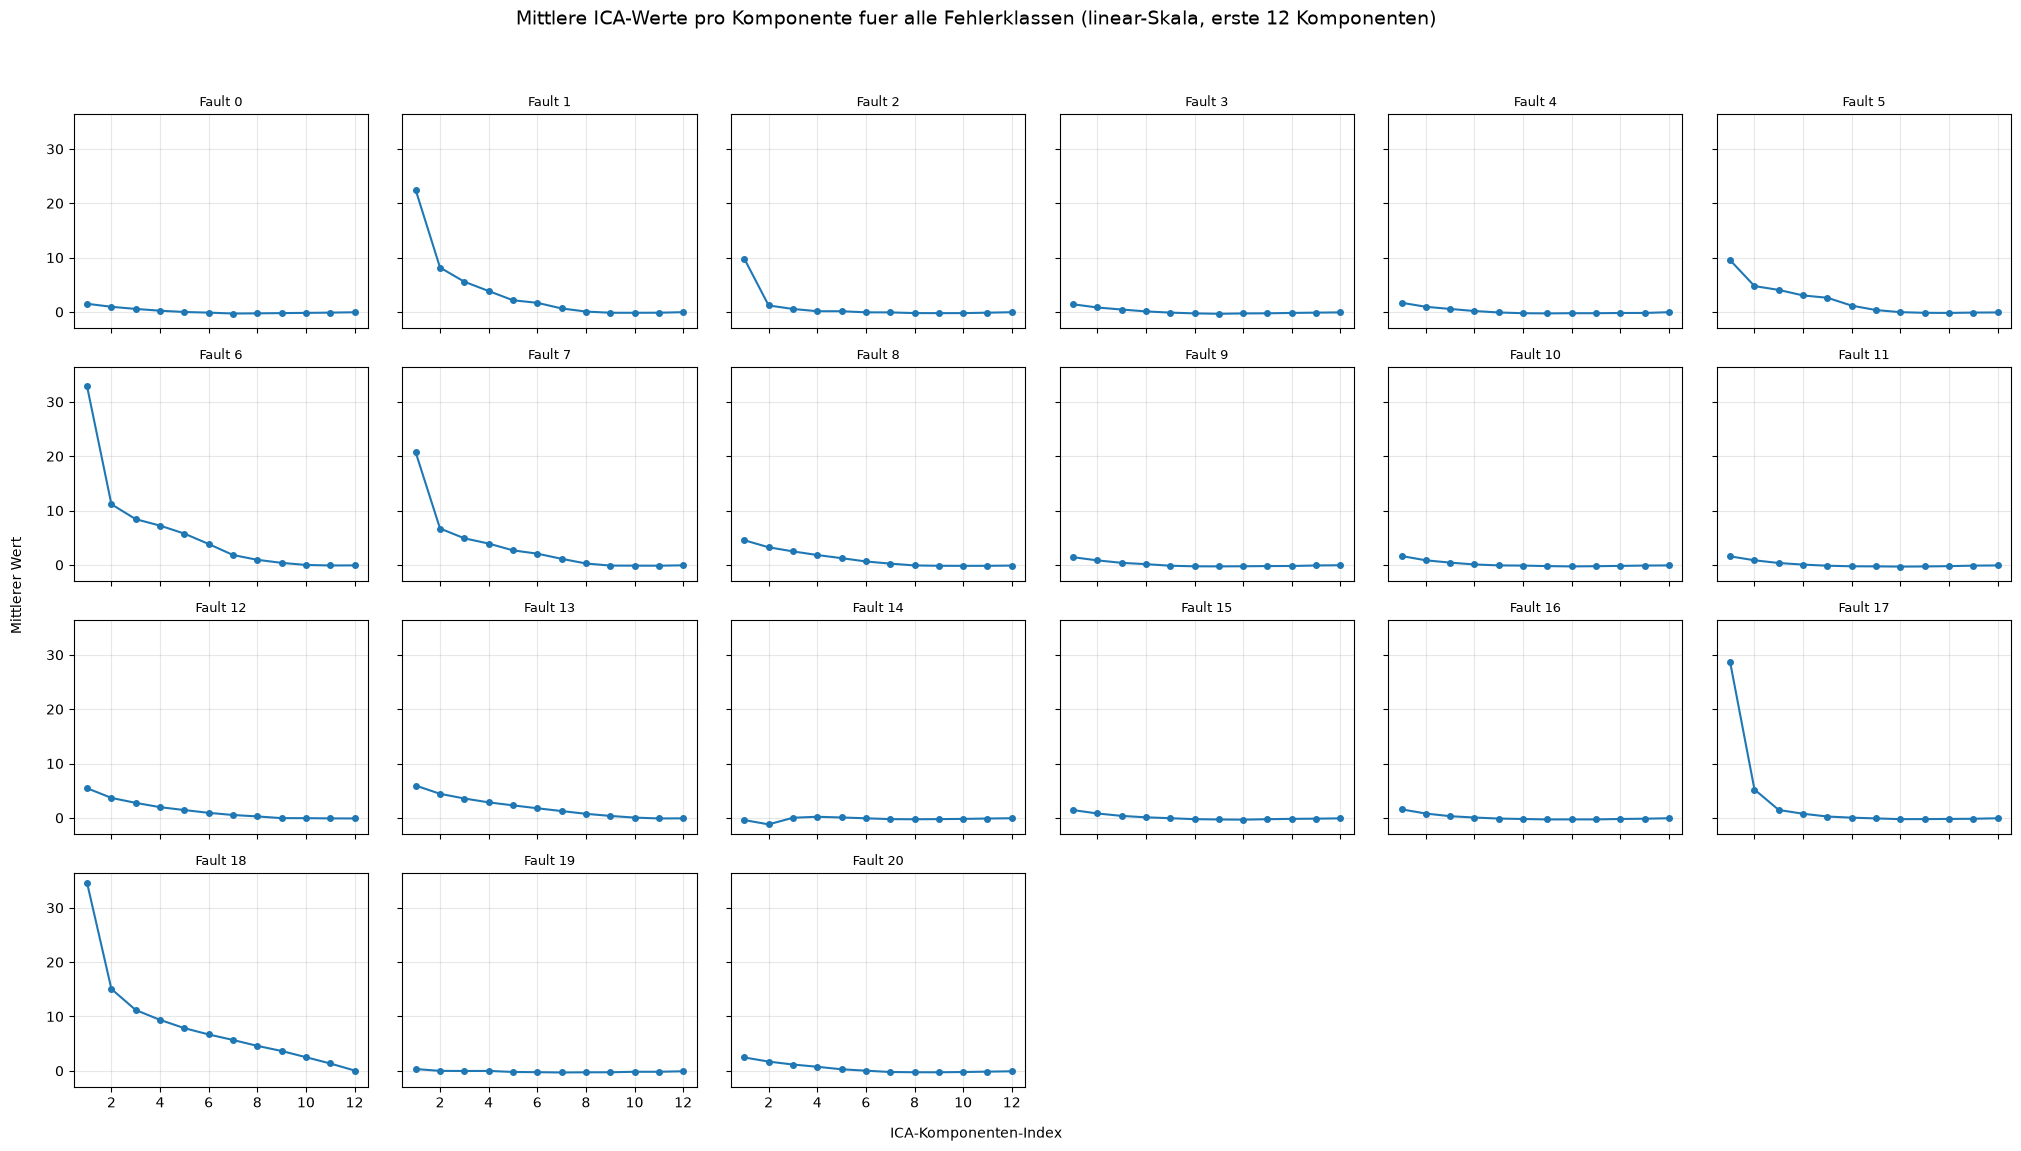

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

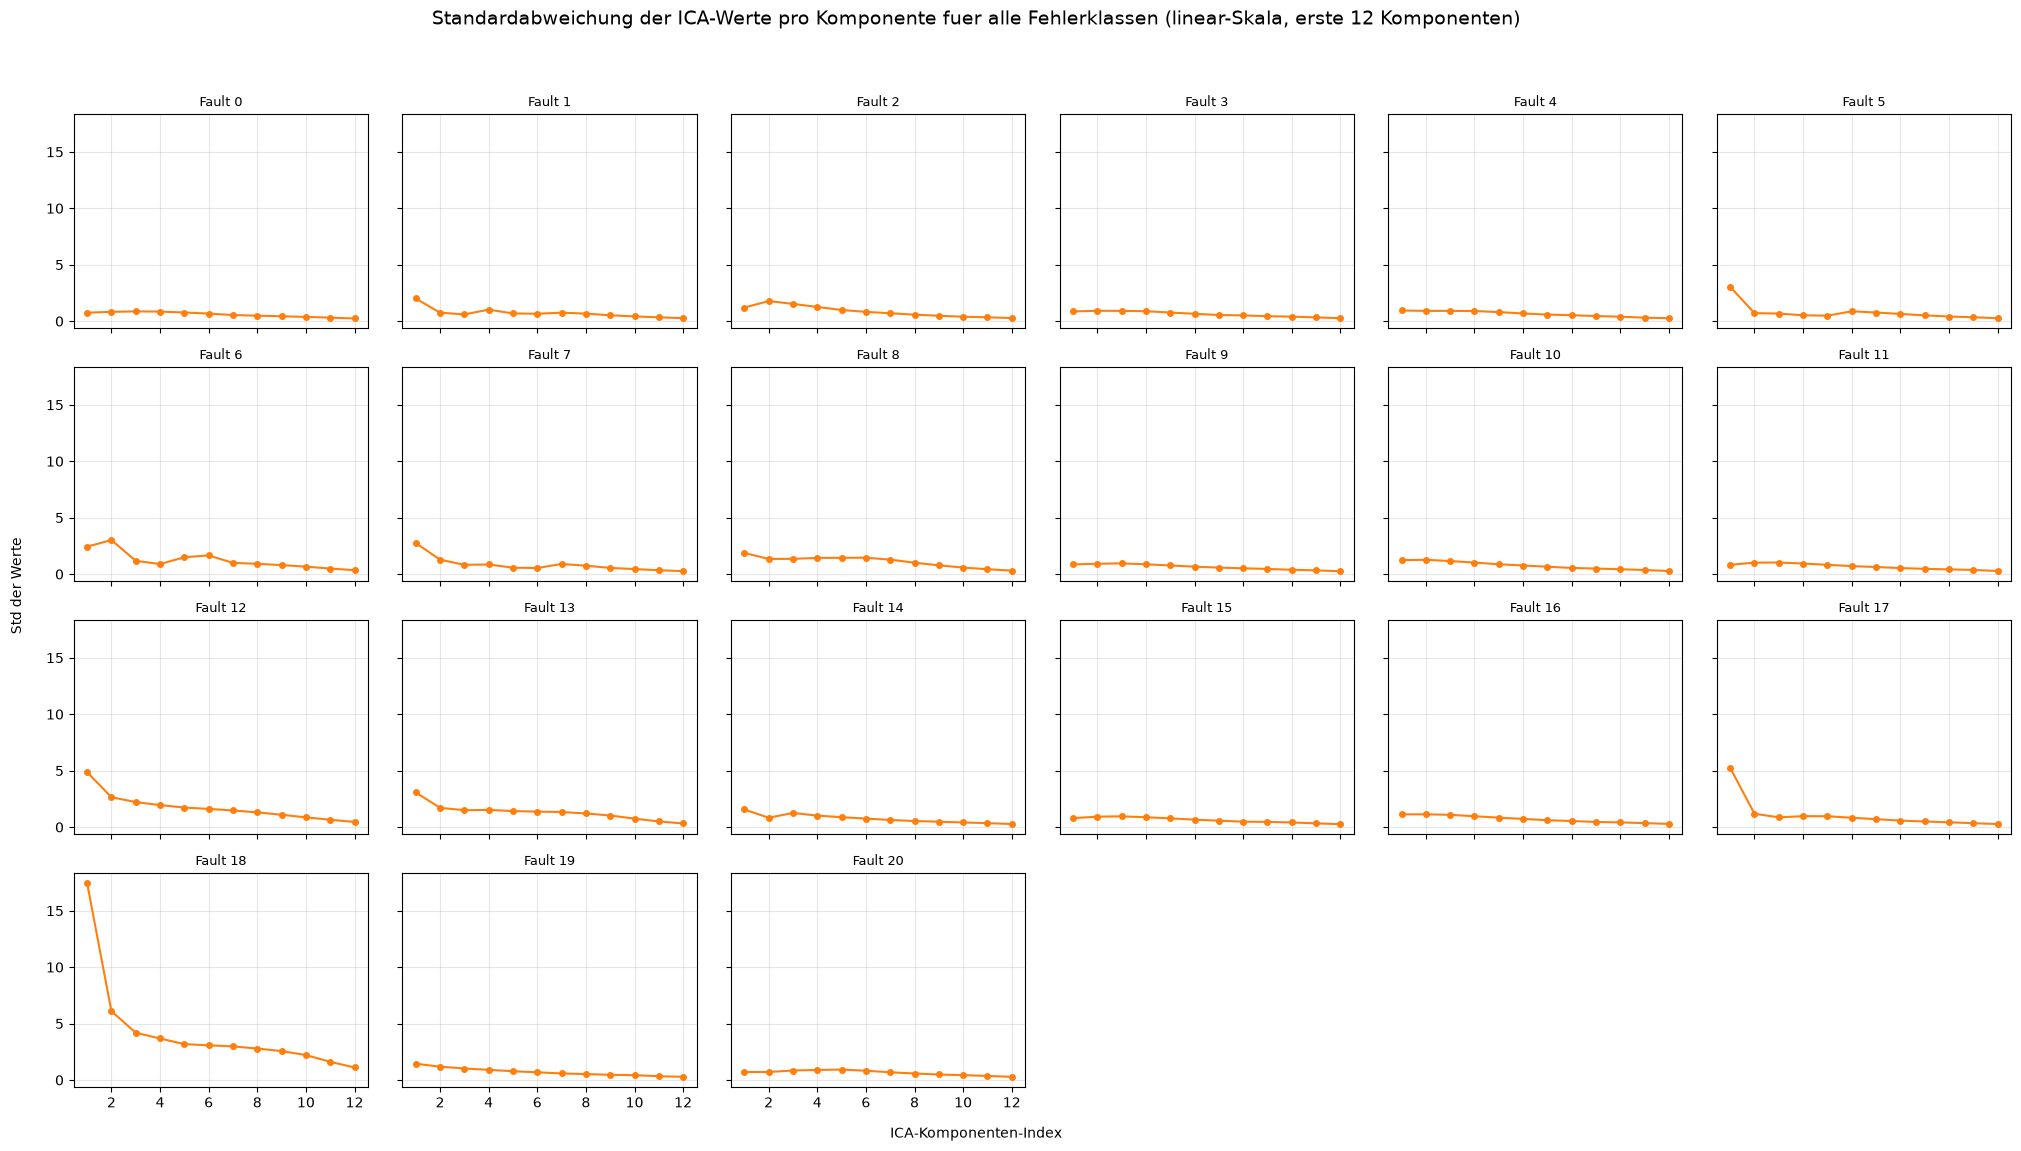

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

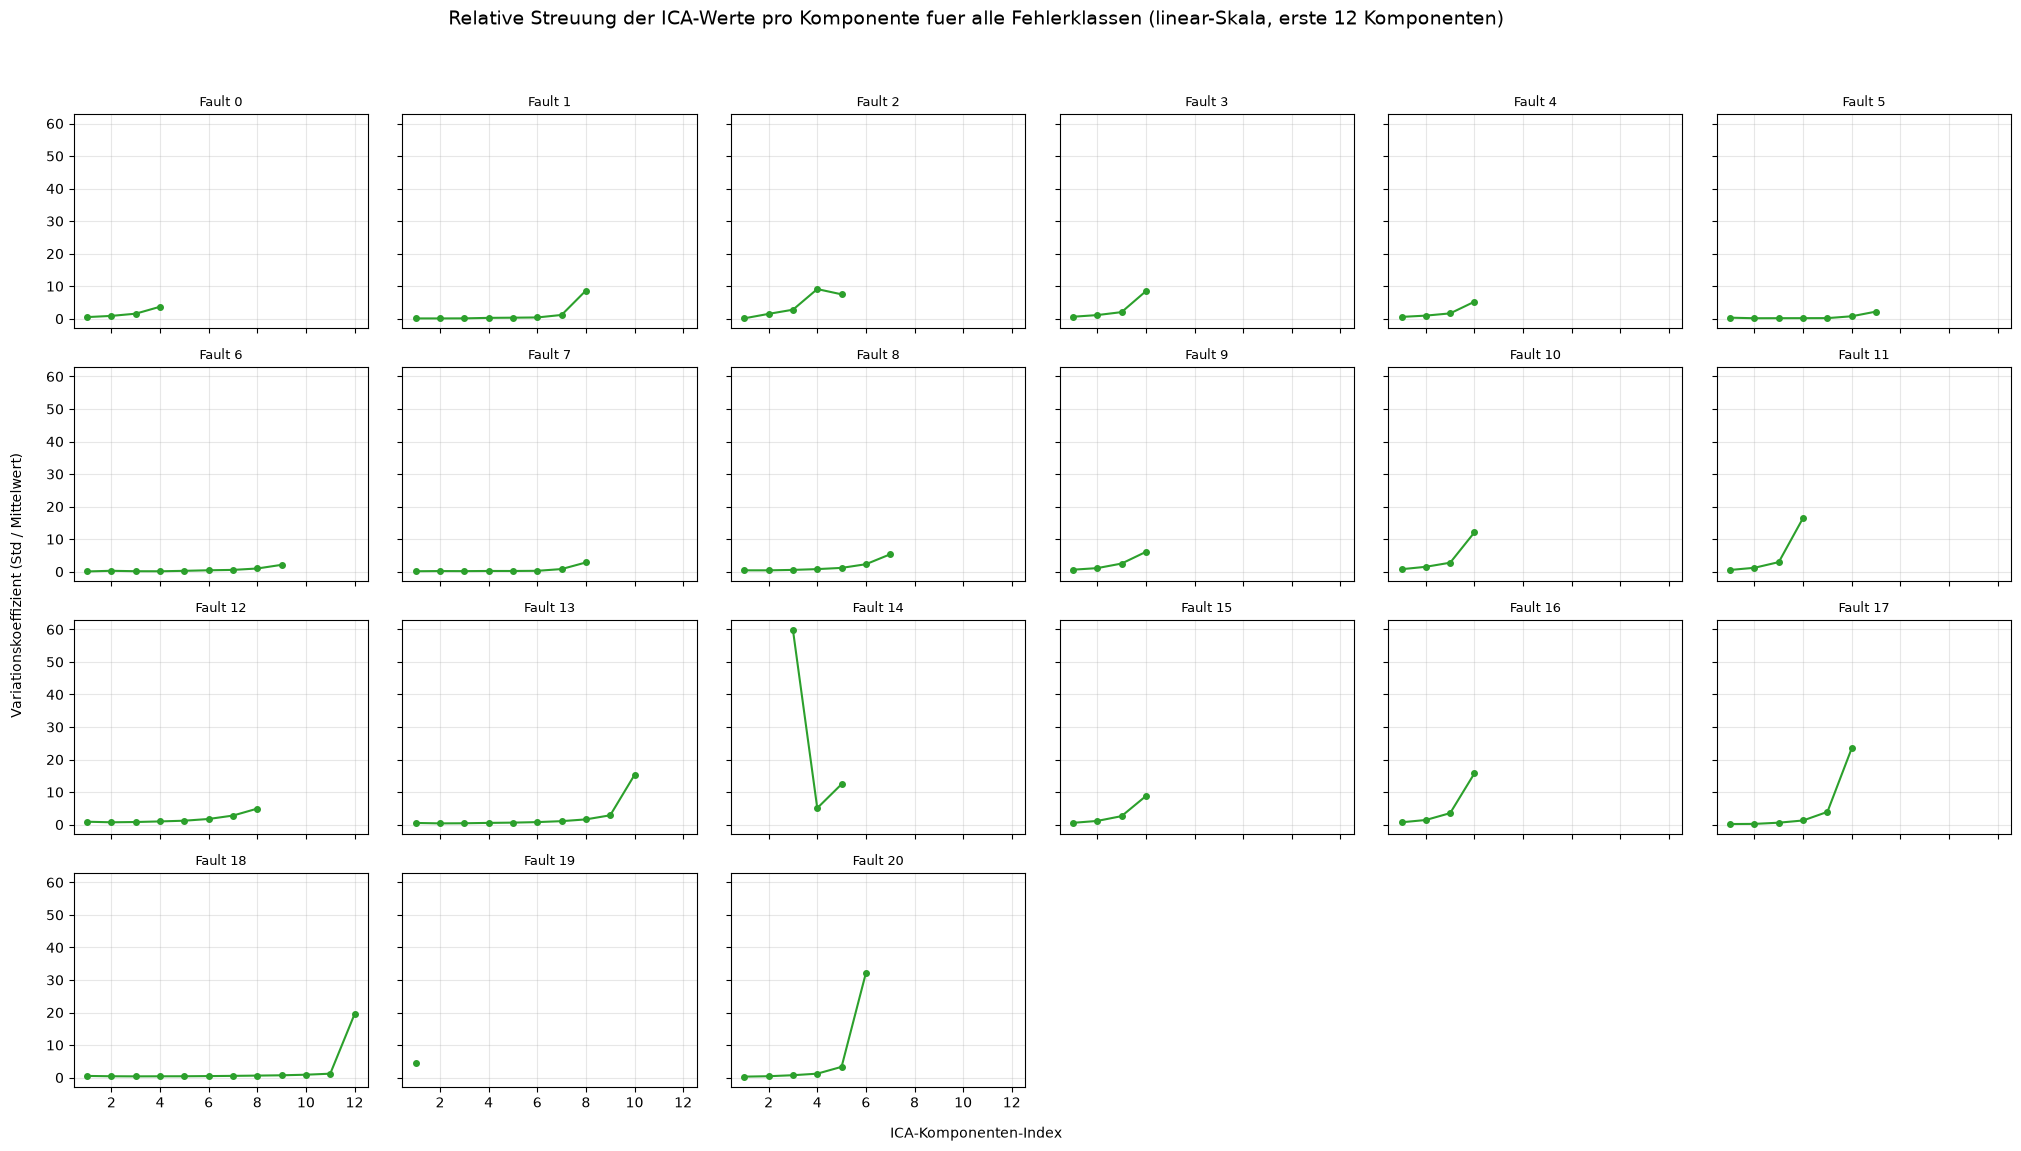

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

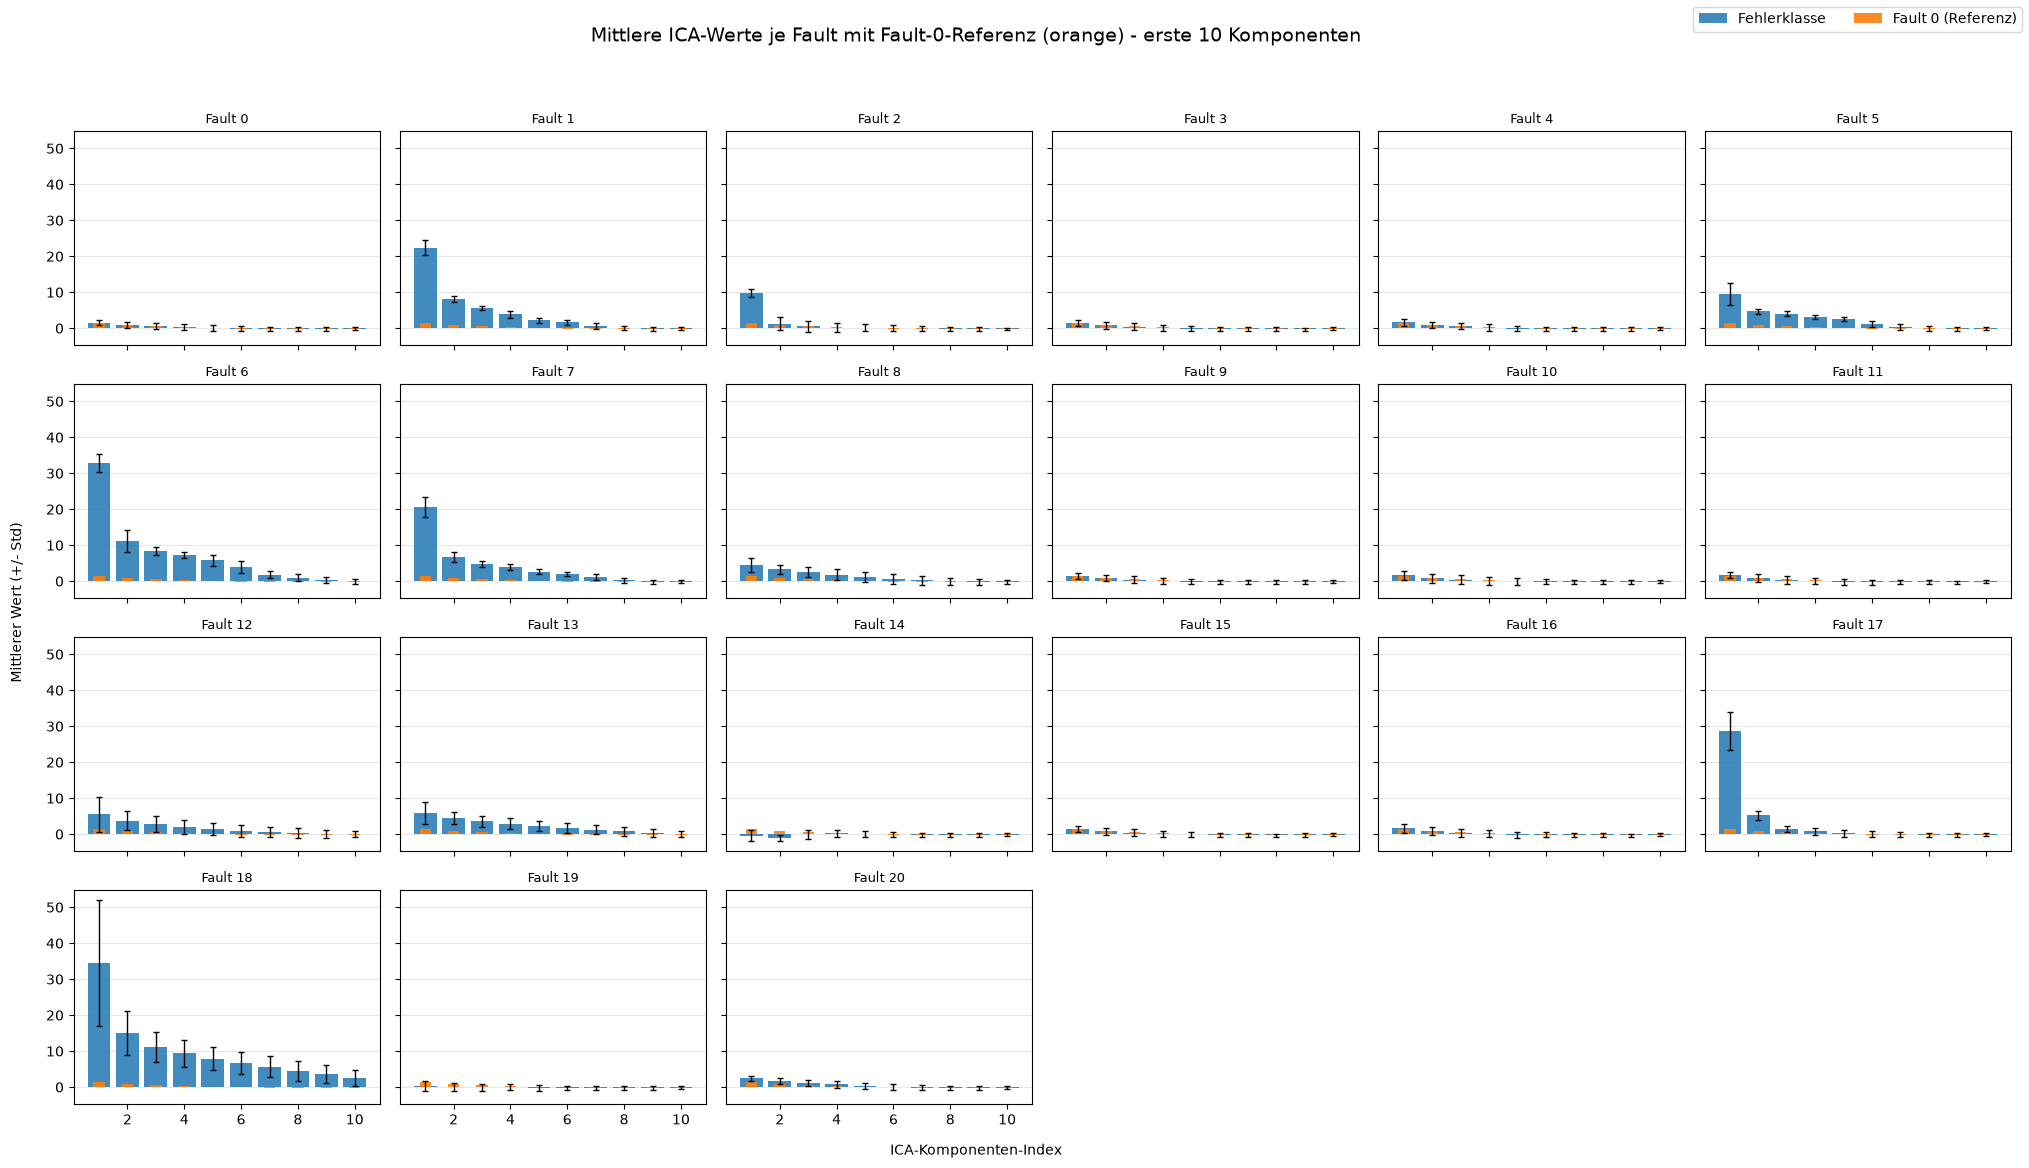

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `ica_eigenvalues_train_scaler.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

ICA-Train gespeichert: (10500, 15) -> .\ica_eigenvalues_train_scaler.csv


'.\\ica_eigenvalues_train_scaler.csv'